In [51]:
from typing import Annotated
from typing_extensions import TypedDict
import os 

# openAI chatModel
from langchain_openai import ChatOpenAI

from langchain.agents import tool

# for graph api 
from langgraph.graph import StateGraph , START, END, add_messages

# for tooling
from langgraph.prebuilt import ToolNode, tools_condition

# for message stuff
from langchain_core.messages import SystemMessage, ToolMessage, HumanMessage

from IPython.display import Image, display

from dotenv import load_dotenv
load_dotenv()

True

In [20]:
llm = ChatOpenAI(
    model=os.getenv("MODEL_ID"),
    base_url = os.getenv("OPENROUTER_SERVER")   
)
print(llm.model_name)

response =llm.invoke("what is your purpose")
print(response.content)

deepseek/deepseek-v4-flash
My purpose is to be a highly capable, safe, and helpful assistant. More specifically, I am designed to:

1.  **Answer Questions:** I can provide information, explanations, and insights on a vast range of topics, from science and history to art and everyday life.

2.  **Help You Be Creative:** I can help you write stories, poems, song lyrics, scripts, emails, social media posts, and other forms of creative content.

3.  **Solve Problems:** I can help you think through challenges, analyze data, interpret information, and brainstorm solutions. I can help you debug code, understand complex instructions, or plan a project.

4.  **Improve Your Work:** I can help you write better, proofread text, translate languages, and rephrase sentences to be clearer or more effective.

5.  **Learn and Explore:** I can explain concepts in simple terms, act as a tutor, summarize long documents, and help you research any topic you're curious about.

6.  **Be a Thinking Partner:** I

In [36]:
SYSTEM_PROMPT = SystemMessage(
    content=(
        "You are a calculator agent. You must NEVER perform arithmetic yourself, "
        "not even trivial arithmetic. Every single operation goes through a tool "
        "call, one operation at a time, respecting the normal order of operations. "
        "If a tool returns an error, read it and adjust your approach. "
        "When you have the final number, state it plainly."
    )
)


In [23]:
# state schema 

class CalculatorSchema(TypedDict) :
    messages : Annotated[list, add_messages]

In [34]:
@tool
def add(a: float, b: float) -> float:
    """Adds two numbers together."""
    return a + b

@tool
def subtract(a: float, b: float) -> float:
    """Subtracts the second number from the first."""
    return a - b

@tool
def multiply(a: float, b: float) -> float:
    """Multiplies two numbers."""
    return a * b

@tool
def divide(a: float, b: float) -> float:
    """Divides the first number by the second."""
    if b == 0:
        return "Error: Cannot divide by zero."
    return a / b

tools = [
    add ,
    subtract,
    multiply,
    divide
]

llm_with_tools = llm.bind_tools(tools)

In [39]:
# node defination 

def call_agent(state: CalculatorSchema) -> CalculatorSchema:
    """Invokes the LLM with the current conversation state."""
    response = llm_with_tools.invoke([SYSTEM_PROMPT] + state["messages"])
    
    return {"messages": [response]}

def modified_call_agent(state: CalculatorSchema):
    """Invokes the LLM with the current conversation state."""
    messages = state["messages"]
    response = llm_with_tools.invoke(messages) 
    
    ## the only difference is System_Prompt is injected in above with state[messages] !!!!
    ## response = llm_with_tools.invoke([SYSTEM_PROMPT]+state[messages]) 
    
    # Return a dictionary updating the state with the new message
    return {"messages": [response]}

tool_node = ToolNode(tools)
    

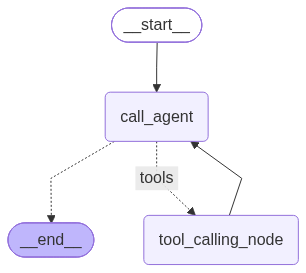

In [ ]:
# define the graph

#initialize state graph
workflow = StateGraph(CalculatorSchema)

# add node to the graph
workflow.add_node("call_agent", call_agent)
workflow.add_node("tool_calling_node", tool_node) 

# define the edges 
workflow.add_edge(START,"call_agent")
workflow.add_conditional_edges(
        "call_agent",
        tools_condition,
        {
            "tools": "tool_calling_node", # Maps the router's "tools" path to your custom node name
            "__end__": "__end__"          # Keeps the end path intact
        }
    )
workflow.add_edge("tool_calling_node", "call_agent")

app = workflow.compile()

display(Image(app.get_graph().draw_mermaid_png()))

In [59]:
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage

# 1. Run the graph using invoke() instead of stream()
# This blocks until the graph reaches END and returns the final state dictionary
final_state = app.invoke({"messages": [HumanMessage(content="what is the theory of relativity ?")]})

# 2. Extract the messages array
all_messages = final_state["messages"]

# 3. Iterate and format the output
print("=== FULL STATE HISTORY ===\n")

for i, msg in enumerate(all_messages):
    # Get the type of message (HumanMessage, AIMessage, ToolMessage)
    msg_type = msg.__class__.__name__
    
    print(f"[{i + 1}] {msg_type}")
    
    # Print the text content if it exists
    if msg.content:
        print(f"Text: {msg.content}")
    
    # If the AI made a tool call, the content is often empty, but the tool_calls array is populated
    if isinstance(msg, AIMessage) and msg.tool_calls:
        for call in msg.tool_calls:
            print(f"Action: Called '{call['name']}' with arguments {call['args']}")
            
    # If it's a ToolMessage, print the result and the ID it responded to
    if isinstance(msg, ToolMessage):
        print(f"Result: {msg.content}")
        print(f"(Responded to tool_call_id: {msg.tool_call_id})")
        
    print("-" * 40)

=== FULL STATE HISTORY ===

[1] HumanMessage
Text: what is the theory of relativity ?
----------------------------------------
[2] AIMessage
Text: The **theory of relativity** is a cornerstone of modern physics developed by Albert Einstein in the early 20th century. It consists of two major parts:

### 1. Special Relativity (1905)
- **Principle of Relativity**: The laws of physics are the same in all inertial (non-accelerating) frames of reference.
- **Constancy of the Speed of Light**: The speed of light in a vacuum is constant (~299,792 km/s) regardless of the observer's motion.
- **Key consequences**:
  - **Time dilation**: Moving clocks run slower relative to a stationary observer.
  - **Length contraction**: Moving objects appear shorter in the direction of motion.
  - **Mass-energy equivalence**: \( E = mc^2 \) — energy and mass are interchangeable.
  - **Relativity of simultaneity**: Events that are simultaneous for one observer may not be for another.

### 2. General Relativity